<a href="https://colab.research.google.com/github/itsmriti/finalassignment_ai/blob/main/final_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
 !pip install ultralytics opencv-python matplotlib

In [3]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import files
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
STUDENT_NAME = "Smriti Khatiwada"
STUDENT_ID = "2347189"

In [6]:
os.makedirs("hw_outputs", exist_ok=True)

In [7]:
# ══════════════════════════════════════════════════════
# SETUP — Run this cell first
# ══════════════════════════════════════════════════════

# Uncomment the line below if packages are not installed
# !pip install ultralytics opencv-python matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
import os

from ultralytics import YOLO

print('OpenCV:', cv2.__version__)
print('NumPy:', np.__version__)
print('Ultralytics YOLO ready')

import torch
if torch.cuda.is_available():
    print(f'GPU available: {torch.cuda.get_device_name(0)}')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print('Apple MPS (Metal) available')
else:
    print('Running on CPU (slower but works fine)')

os.makedirs('hw_outputs', exist_ok=True)
print('\nSetup complete!')

OpenCV: 4.13.0
NumPy: 2.0.2
Ultralytics YOLO ready
Running on CPU (slower but works fine)

Setup complete!


street.jpg already exists
office.jpg already exists
Synthetic bin scene created


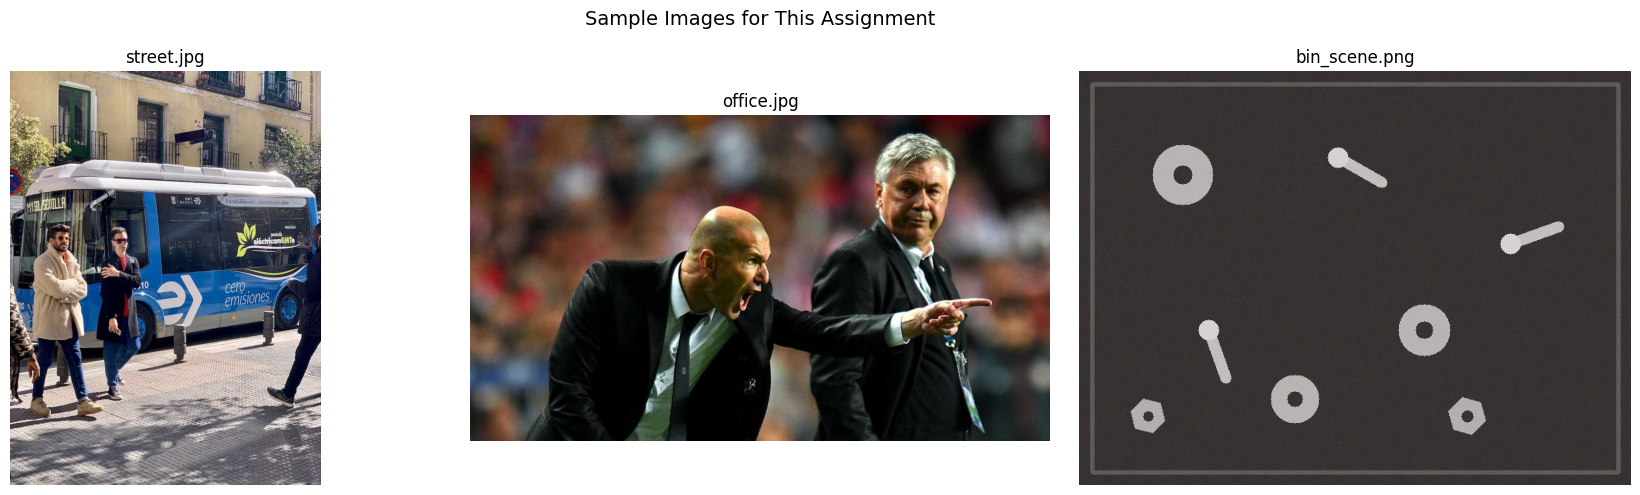

In [9]:
# ══════════════════════════════════════════════════════
# DOWNLOAD / PREPARE SAMPLE IMAGES
# ══════════════════════════════════════════════════════

import urllib.request

sample_urls = {
    "street.jpg": "https://ultralytics.com/images/bus.jpg",
    "office.jpg": "https://ultralytics.com/images/zidane.jpg",
}

os.makedirs('sample_images', exist_ok=True)

for filename, url in sample_urls.items():
    filepath = f'sample_images/{filename}'
    if not os.path.exists(filepath):
        print(f'Downloading {filename}...')
        urllib.request.urlretrieve(url, filepath)
    else:
        print(f'{filename} already exists')


def create_bin_scene(width=640, height=480):
    """Create a synthetic overhead bin scene with shapes (washers, bolts, nuts)."""
    img = np.zeros((height, width, 3), dtype=np.uint8)
    img[:] = (50, 50, 55)
    cv2.rectangle(img, (15, 15), (width-15, height-15), (90, 90, 95), 3)

    # Washers (circles with holes)
    for (cx, cy, r) in [(120, 120, 35), (400, 300, 30), (250, 380, 28)]:
        cv2.circle(img, (cx, cy), r, (180, 180, 185), -1)
        cv2.circle(img, (cx, cy), r // 3, (50, 50, 55), -1)

    # Bolts (lines with circle heads)
    for (cx, cy, angle) in [(300, 100, 30), (500, 200, -20), (150, 300, 70)]:
        length, thick = 60, 12
        dx = int(length * np.cos(np.radians(angle)))
        dy = int(length * np.sin(np.radians(angle)))
        cv2.line(img, (cx, cy), (cx+dx, cy+dy), (190, 190, 195), thick)
        cv2.circle(img, (cx, cy), thick, (210, 210, 215), -1)

    # Nuts (hexagons with holes)
    for (cx, cy, sz) in [(450, 400, 22), (80, 400, 20)]:
        pts = []
        for i in range(6):
            a = np.radians(60 * i + 15)
            pts.append([int(cx + sz*np.cos(a)), int(cy + sz*np.sin(a))])
        cv2.fillPoly(img, [np.array(pts)], (175, 175, 180))
        cv2.circle(img, (cx, cy), sz // 3, (50, 50, 55), -1)

    noise = np.random.normal(0, 4, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return img


bin_scene = create_bin_scene()
cv2.imwrite('sample_images/bin_scene.png', bin_scene)
print('Synthetic bin scene created')

# Display all sample images
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, fname in zip(axes, ['street.jpg', 'office.jpg', 'bin_scene.png']):
    img = cv2.imread(f'sample_images/{fname}')
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(fname, fontsize=12)
    ax.axis('off')
plt.suptitle('Sample Images for This Assignment', fontsize=14)
plt.tight_layout()
plt.show()


image 1/1 /content/sample_images/street.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 484.9ms
Speed: 16.8ms preprocess, 484.9ms inference, 40.7ms postprocess per image at shape (1, 3, 640, 480)


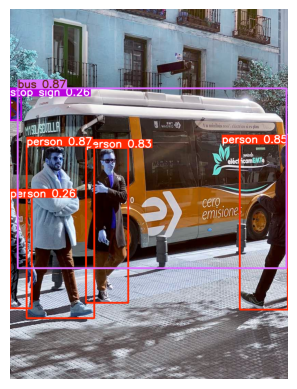


Detection Summary:
Class             Conf Box (x1,y1,x2,y2)
-------------------------------------------------------
bus               0.87 [22.87126922607422, 231.27731323242188, 805.002685546875, 756.84033203125]
person            0.87 [48.55046844482422, 398.5522155761719, 245.34556579589844, 902.7026977539062]
person            0.85 [669.472900390625, 392.1861267089844, 809.7201538085938, 877.0354614257812]
person            0.83 [221.5172882080078, 405.79864501953125, 344.9706115722656, 857.53662109375]
person            0.26 [0.0, 550.5250244140625, 63.00695037841797, 873.4429321289062]
stop sign         0.26 [0.05817067623138428, 254.4593963623047, 32.55740737915039, 324.8741455078125]


In [10]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

# Load YOLOv8 nano model
model_detect = YOLO("yolov8n.pt")

# Run inference on street image
results = model_detect("sample_images/street.jpg")

# Display annotated image
plt.imshow(results[0].plot())
plt.axis("off")
plt.show()


# Print detection details
print('\nDetection Summary:')
print(f'{"Class":<15} {"Conf":>6} {"Box (x1,y1,x2,y2)"}')
print('-' * 55)

boxes = results[0].boxes
names = results[0].names

for box in boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    coords = box.xyxy[0].tolist()

    print(f'{names[cls]:<15} {conf:>6.2f} {coords}')

Total objects detected: 6


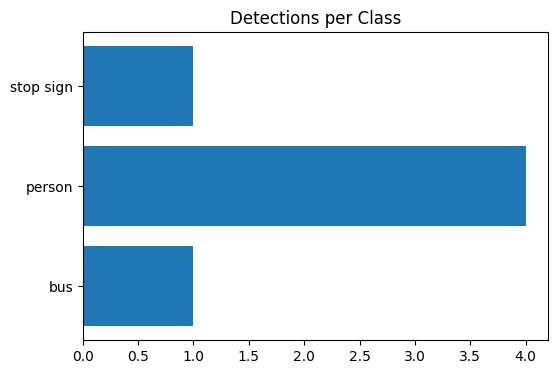

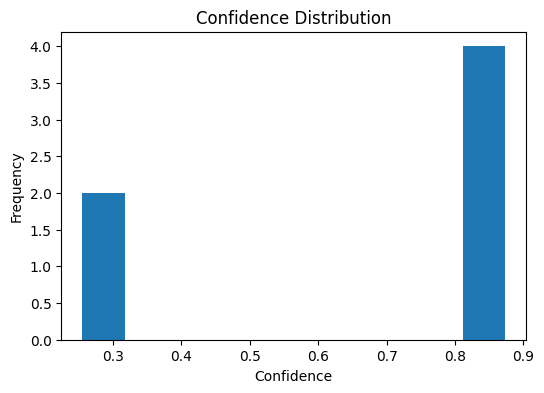


High-confidence detections (conf >= 0.7):
--------------------------------------------------
bus 0.8734486699104309
person 0.8656910061836243
person 0.8528357148170471
person 0.8252248764038086


In [11]:
from collections import Counter

boxes = results[0].boxes
names = results[0].names

# Count detections
classes = [names[int(c)] for c in boxes.cls]
total_detections = len(classes)

print(f'Total objects detected: {total_detections}')

# Bar chart of detections
counts = Counter(classes)

plt.figure(figsize=(6,4))
plt.barh(list(counts.keys()), list(counts.values()))
plt.title("Detections per Class")
plt.show()

# Histogram of confidence scores
confs = [float(c) for c in boxes.conf]

plt.figure(figsize=(6,4))
plt.hist(confs, bins=10)
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

# High confidence detections
print('\nHigh-confidence detections (conf >= 0.7):')
print('-' * 50)

for box in boxes:
    conf = float(box.conf[0])
    cls = int(box.cls[0])

    if conf >= 0.7:
        print(names[cls], conf)

In [13]:
from google.colab import files
uploaded = files.upload()
my_image_path = list(uploaded.keys())[0]

Saving street.jpg to street.jpg



image 1/1 /content/street.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 316.8ms
Speed: 8.9ms preprocess, 316.8ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 480)


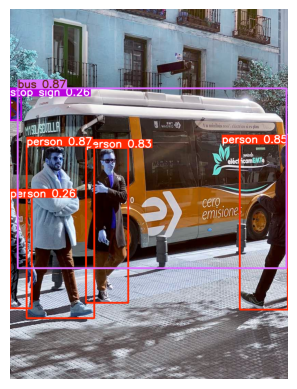

Detections in my image:
--------------------------------------------------
bus 0.8734486699104309 [22.87126922607422, 231.27731323242188, 805.002685546875, 756.84033203125]
person 0.8656910061836243 [48.55046844482422, 398.5522155761719, 245.34556579589844, 902.7026977539062]
person 0.8528357148170471 [669.472900390625, 392.1861267089844, 809.7201538085938, 877.0354614257812]
person 0.8252248764038086 [221.5172882080078, 405.79864501953125, 344.9706115722656, 857.53662109375]
person 0.26111191511154175 [0.0, 550.5250244140625, 63.00695037841797, 873.4429321289062]
stop sign 0.255070298910141 [0.05817067623138428, 254.4593963623047, 32.55740737915039, 324.8741455078125]


True

In [14]:
# Run detection
my_results = model_detect(my_image_path)

# Display annotated image
plt.imshow(my_results[0].plot())
plt.axis("off")
plt.show()

# Print detections
print('Detections in my image:')
print('-' * 50)

boxes = my_results[0].boxes
names = my_results[0].names

for box in boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    coords = box.xyxy[0].tolist()

    print(names[cls], conf, coords)

# Save annotated image
import cv2
cv2.imwrite("hw_outputs/task1_3_my_image.jpg", my_results[0].plot())


image 1/1 /content/sample_images/street.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 261.3ms
Speed: 6.4ms preprocess, 261.3ms inference, 9.9ms postprocess per image at shape (1, 3, 640, 480)


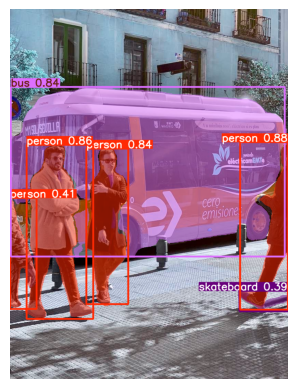

Segmentation Summary:
--------------------------------------------------
person 0.8777946829795837
person 0.8602195382118225
person 0.8412285447120667
bus 0.8381743431091309
person 0.411940336227417
skateboard 0.3919503688812256


In [16]:
#YOLO SEGMENTATION

# Load segmentation model
model_seg = YOLO("yolov8n-seg.pt")

# Run segmentation
results_seg = model_seg("sample_images/street.jpg")

# Display annotated image
plt.imshow(results_seg[0].plot())
plt.axis("off")
plt.show()

# Summary
print('Segmentation Summary:')
print('-' * 50)

boxes = results_seg[0].boxes
names = results_seg[0].names

for box in boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    print(names[cls], conf)


Mask Statistics:
Object                      Pixel Area   Coverage %
--------------------------------------------------
person                            7740        2.52
person                           18259        5.94
person                           12379        4.03
bus                              91719       29.86
person                            4375        1.42
skateboard                         967        0.31


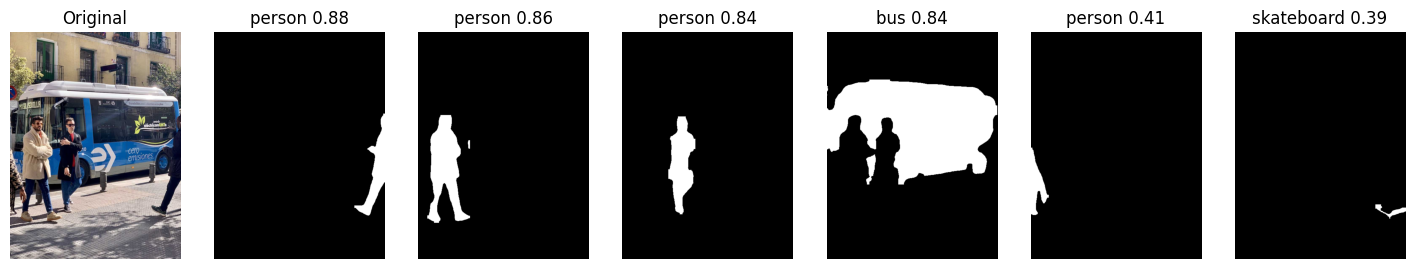

In [17]:
#Extract Individual Mask
masks_tensor = results_seg[0].masks.data
masks_np = masks_tensor.cpu().numpy()

boxes = results_seg[0].boxes
names = results_seg[0].names

N = min(6, len(masks_np))

fig, axes = plt.subplots(1, N+1, figsize=(18,5))

original = cv2.imread("sample_images/street.jpg")
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")

print('\nMask Statistics:')
print(f'{"Object":<25} {"Pixel Area":>12} {"Coverage %":>12}')
print('-' * 50)

H, W = masks_np[0].shape

for i in range(N):
    mask = masks_np[i]

    axes[i+1].imshow(mask, cmap="gray")
    axes[i+1].axis("off")

    cls = int(boxes.cls[i])
    conf = float(boxes.conf[i])

    axes[i+1].set_title(f"{names[cls]} {conf:.2f}")

    pixel_area = np.sum(mask > 0.5)
    coverage = pixel_area/(H*W)*100

    print(f'{names[cls]:<25} {pixel_area:>12} {coverage:>11.2f}')

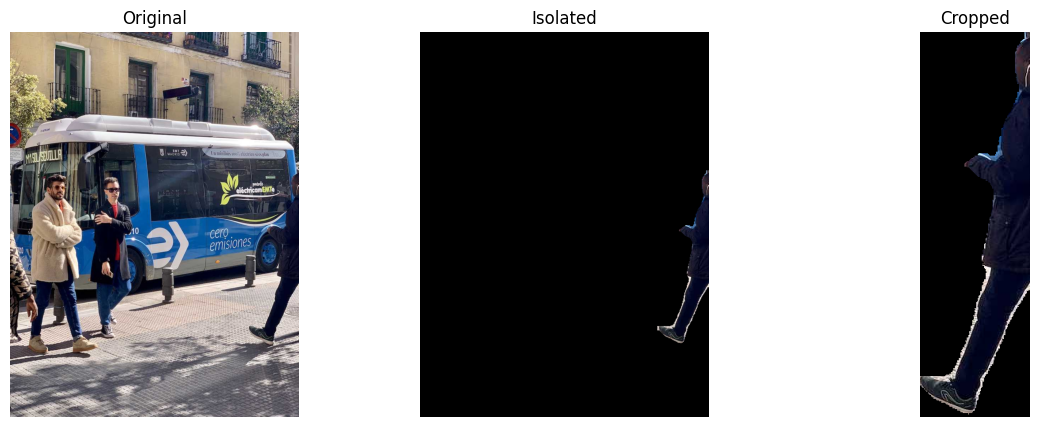

True

In [18]:
# Make sure segmentation was already run:
# results_seg = model_seg("street.jpg")

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Get original image
original = cv2.imread("sample_images/street.jpg")
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

H_orig, W_orig = original_rgb.shape[:2]

# Get masks and boxes
masks_np = results_seg[0].masks.data.cpu().numpy()
boxes = results_seg[0].boxes

# Choose object index (first object)
OBJECT_INDEX = 0

# Get mask
mask = masks_np[OBJECT_INDEX]

# Resize mask to original image size
mask_resized = cv2.resize(mask, (W_orig, H_orig))

# Convert to binary
mask_binary = (mask_resized > 0.5).astype(np.uint8)

# Isolate object
isolated = original_rgb * mask_binary[:, :, None]

# Get bounding box
box = boxes.xyxy[OBJECT_INDEX].cpu().numpy().astype(int)
x1, y1, x2, y2 = box

# Crop object
cropped = isolated[y1:y2, x1:x2]

# Display
fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(original_rgb)
axes[0].set_title("Original")

axes[1].imshow(isolated)
axes[1].set_title("Isolated")

axes[2].imshow(cropped)
axes[2].set_title("Cropped")

for ax in axes:
    ax.axis("off")

plt.show()

# Save result
cv2.imwrite("hw_outputs/task2_3_isolated.jpg",
            cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))


image 1/1 /content/street.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 269.3ms
Speed: 5.8ms preprocess, 269.3ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)


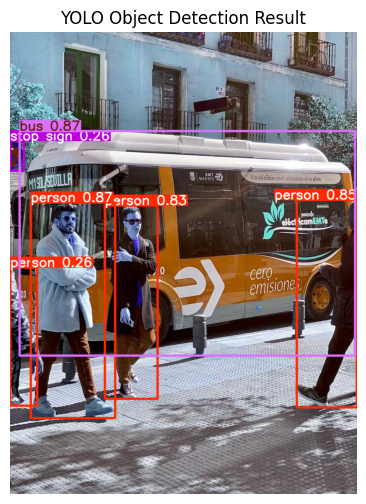

Detected Objects:
bus - Confidence: 0.87
person - Confidence: 0.87
person - Confidence: 0.85
person - Confidence: 0.83
person - Confidence: 0.26
stop sign - Confidence: 0.26


In [21]:
# Install YOLO
!pip install ultralytics

# Import libraries
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLO model
model = YOLO("yolov8n.pt")

# Path to your uploaded image
image_path = "/content/street.jpg"

# Run detection
results = model(image_path)

# Read image for display
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Plot results
plt.figure(figsize=(10,6))
plt.imshow(results[0].plot())
plt.axis("off")
plt.title("YOLO Object Detection Result")
plt.show()

# Print detected objects
print("Detected Objects:")
for box in results[0].boxes:
    cls_id = int(box.cls)
    label = model.names[cls_id]
    confidence = float(box.conf)
    print(f"{label} - Confidence: {confidence:.2f}")